In [1]:
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


In [2]:
# A. Membangun Struktur Direktori HDFS
!hdfs dfs -mkdir -p /user/zeno/ecommerce/raw
!hdfs dfs -mkdir -p /user/zeno/ecommerce/processed

# Verifikasi struktur direktori yang telah dibuat
!hdfs dfs -ls /user/zeno/ecommerce

Found 2 items
drwxr-xr-x   - zeno supergroup          0 2026-09-09 19:44 /user/zeno/ecommerce/processed
drwxr-xr-x   - zeno supergroup          0 2026-09-09 19:44 /user/zeno/ecommerce/raw


In [3]:
# B. Mengunggah Data Mentah ke HDFS
!hdfs dfs -put transaksi_magelang.csv transaksi_yogyakarta.csv transaksi_semarang.csv /user/zeno/ecommerce/raw/

!hdfs dfs -ls -h /user/zeno/ecommerce/raw

Found 3 items
-rw-r--r--   1 zeno supergroup     12.0 K 2026-09-09 19:48 /user/zeno/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 zeno supergroup     11.9 K 2026-09-09 19:48 /user/zeno/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 zeno supergroup     12.4 K 2026-09-09 19:48 /user/zeno/ecommerce/raw/transaksi_yogyakarta.csv


In [4]:
# C. Membaca Kembali dan Menggabungkan Data dari HDFS
import io
import pandas as pd

daftar_kota = ["magelang", "yogyakarta", "semarang"]
list_df = []

for kota in daftar_kota:
    path_hdfs = f"/user/zeno/ecommerce/raw/transaksi_{kota}.csv"
    konten_csv = !hdfs dfs -cat {path_hdfs}

    data_stream = io.StringIO("\n".join(konten_csv))
    df = pd.read_csv(data_stream)
    list_df.append(df)

# Menggabungkan ketiga DataFrame menjadi satu
df_gabungan = pd.concat(list_df, ignore_index=True)

# Bukti hasil gabungan berisi transaksi dari ketiga kota
print("--- Jumlah Transaksi per Kota ---")
print(df_gabungan["kota"].value_counts())

# Menampilkan total baris dan contoh 5 data teratas
print(f"\nTotal baris gabungan: {len(df_gabungan)}")
df_gabungan.head()

--- Jumlah Transaksi per Kota ---
kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64

Total baris gabungan: 600


,order_id,tanggal,kategori,unit_terjual,harga_satuan,metode_pembayaran,kota
0,MAG-2000,2026-08-12,Fashion,1,50000,Transfer Bank,Magelang
1,MAG-2001,2026-08-18,Elektronik,7,25000,COD,Magelang
2,MAG-2002,2026-08-07,Elektronik,7,25000,E-Wallet,Magelang
3,MAG-2003,2026-08-24,Rumah Tangga,6,25000,COD,Magelang
4,MAG-2004,2026-08-30,Fashion,7,100000,Transfer Bank,Magelang


In [5]:
# D. Mengolah dan Download Hasil ke Direktori processed

# Menambahkan kolom total_pendapatan
df_gabungan["total_pendapatan"] = (
    df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]
)

# Membuat tabel ringkasan per kota dan per kategori
df_ringkasan = (
    df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"]
    .sum()
    .reset_index()
)

print("--- Tabel Ringkasan Pendapatan per Kota dan Kategori ---")
display(df_ringkasan)

# Menyimpan kedua hasil ke disk lokal
df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

# Mengunggah kedua berkas CSV dari disk lokal ke /processed di HDFS
!hdfs dfs -put data_gabungan_bersih.csv ringkasan_kota_kategori.csv /user/zeno/ecommerce/processed/

# Verifikasi isi direktori /processed di HDFS
print("\n--- Isi Direktori /processed di HDFS ---")
!hdfs dfs -ls -h /user/zeno/ecommerce/processed

--- Tabel Ringkasan Pendapatan per Kota dan Kategori ---


,kota,kategori,total_pendapatan
0,Magelang,Elektronik,18775000
1,Magelang,Fashion,27750000
2,Magelang,Kesehatan & Kecantikan,17375000
3,Magelang,Makanan & Minuman,17525000
4,Magelang,Rumah Tangga,12200000
5,Semarang,Elektronik,21425000
6,Semarang,Fashion,26425000
7,Semarang,Kesehatan & Kecantikan,13525000
8,Semarang,Makanan & Minuman,19750000
9,Semarang,Rumah Tangga,10975000



--- Isi Direktori /processed di HDFS ---
Found 2 items
-rw-r--r--   1 zeno supergroup     40.3 K 2026-09-09 20:00 /user/zeno/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 zeno supergroup        530 2026-09-09 20:00 /user/zeno/ecommerce/processed/ringkasan_kota_kategori.csv


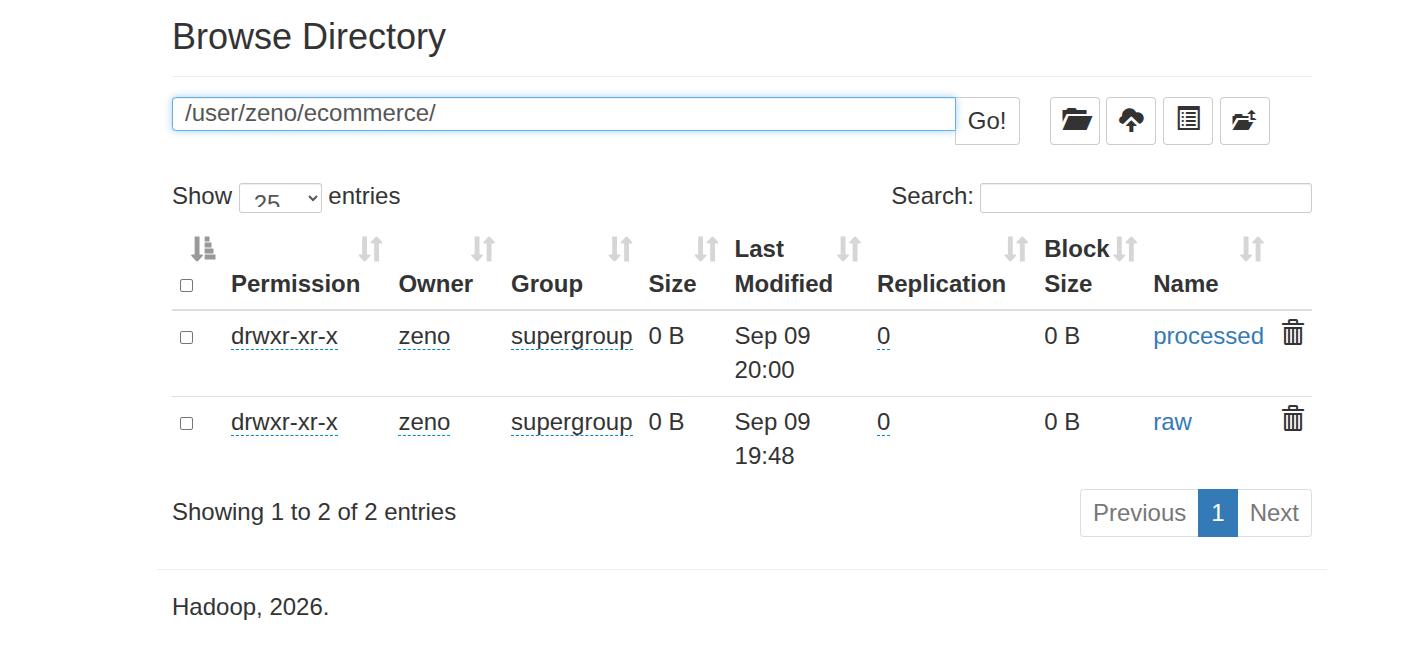

### Refleksi: Alasan Memisahkan Folder Raw dan Processed di HDFS

Memisahkan folder data mentah raw dan data processed di HDFS punya banyak keuntungan dibandingkan menggabungkannya di satu tempat. 

Alasan utamanya adalah keamanan data asli. Data mentah di folder raw berfungsi sebagai cadangan utama yang tidak boleh diubah-ubah. Jika suatu saat kita melakukan kesalahan saat mengolah data atau kodenya salah hitung, kita tidak perlu panik karena data aslinya masih aman tersimpan. Kita bisa langsung mengolah ulang data mentah tersebut dari awal kapan saja.

Selain itu, struktur ini membuat pekerjaan kita jadi jauh lebih rapi dan teratur. Ketika direktori terpisah, kita bisa mencari dan membedakan mana berkas yang masih asli dan mana berkas hasil analisis dengan sangat cepat tanpa takut tertukar. Pemisahan folder ini juga memudahkan jika nanti ada anggota tim lain yang ingin mengakses data, karena folder data mentah bisa dikunci agar tidak sengaja terhapus atau terubah oleh orang lain.